# Estimability and Profile Likelihood: Historical Data vs Historical + Lot 1

This notebook compares parameter estimability before and after adding the executed Lot 1 data.

The workflow follows the same model-based design logic used in the campaign:

1. Load historical normalized natural/synthetic must data.
2. Reconstruct Lot 1 as executable model batches using actual initial states, sampling times and pulse logs.
3. Fit the core kinetic parameter block for both information sets.
4. Compute FIM, covariance approximations, eigenvalue diagnostics and weak directions.
5. Run profile likelihood for selected weak core kinetic parameters.

The extended FIM includes observed core and secondary states. Online CO2 is included as an information-time block, not as a final flow-calibrated likelihood, because the current model state is cumulative CO2 while the sensor reports gas flow.

The executed notebook uses a screening profile likelihood for `Kd0` and `qN` to keep the old-vs-new comparison operational. To make a more exhaustive profile, rerun the analysis cell with more parameters, for example `("Kd0", "qN", "qEG", "betaG0")`, and increase `grid_points` and `profile_nfev`.

The core fit uses a small deterministic polish/multistart around `qN` and `Kd0`. This is included because the profile likelihood can otherwise reveal a lower objective than the initial least-squares solution.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

from laboratory_2026 import run_estimability_old_vs_lot1 as analysis

RESULTS = Path("laboratory_2026") / "results" / "estimability_old_vs_lot1"


## Run Analysis

In [2]:
analysis.run_analysis(
    profile_parameters=("Kd0", "qN"),
    grid_points=3,
    fit_nfev=300,
    profile_nfev=45,
    step=0.04,
)

[fit] historical_only


[fim-core] historical_only


[fim-extended] historical_only


[profile] historical_only: Kd0, qN


[fit] historical_plus_lot1


[fim-core] historical_plus_lot1


[fim-extended] historical_plus_lot1


[profile] historical_plus_lot1: Kd0, qN


[done] estimability/profile comparison complete


## Batch Inventory

In [3]:
batch_summary = pd.read_csv(RESULTS / "batch_summary.csv")
display(batch_summary)

,case,medium,batch,n_time,t_min_h,t_max_h,X0,Xd0,N0,G0,F0,E0,Gly0,n_core_obs,n_secondary_obs,pulses
0,historical_only,natural,LAB004,14,0.0,163.0,0.393900,0.009300,0.23076,75.04,70.81,9.707652,0.99,81,0,N:68@0.08
1,historical_only,natural,LAB005,14,0.0,163.0,0.493200,0.015900,0.22730,77.71,87.95,9.786576,1.09,81,0,N:68@0.08
2,historical_only,natural,LAB006,16,0.0,211.0,0.099000,0.027600,0.22912,81.63,75.81,9.865500,1.17,93,0,N:99@0.08
3,historical_only,natural,LAB007,14,0.0,160.0,0.291600,0.000900,0.23904,77.52,74.55,11.759676,0.89,84,0,N:65@0.08
4,historical_only,natural,LAB008,14,0.0,160.0,0.253500,0.003300,0.23922,76.21,74.89,9.234108,0.85,84,0,N:65@0.08
5,historical_only,natural,LAB009,13,0.0,160.0,0.360300,0.000900,0.23740,75.75,76.68,9.707652,0.75,77,0,N:41@0.08
6,historical_only,natural,LAB010,10,0.0,187.0,0.960900,0.112800,0.22570,78.49,77.05,9.313032,1.25,38,0,N:79@0.08
7,historical_only,natural,LAB011,8,0.0,163.0,1.065600,0.038100,0.22024,75.61,76.67,9.313032,1.25,34,0,N:72@0.08
8,historical_only,natural,LAB012,9,0.0,163.0,0.851400,0.120900,0.22206,75.00,79.88,9.391956,1.27,36,0,N:72@0.08
9,historical_only,synthetic,MS007,10,0.0,213.0,0.333000,0.117000,0.22400,125.34,120.52,0.000000,0.34,57,0,N:24@0.1


## FIM Metrics

In [4]:
fit_candidates = pd.read_csv(RESULTS / "core_fit_candidate_summary.csv")
display(fit_candidates[["case", "seed", "final_wsse", "nfev", "success"]])

fim_metrics = pd.read_csv(RESULTS / "fim_metrics_by_case.csv")
display(fim_metrics)

,case,seed,final_wsse,nfev,success
0,historical_only,seed_default,23882.788576,7,True
1,historical_only,qN_up_25pct,23859.608424,8,True
2,historical_only,Kd0_up_2x,23895.443166,8,True
3,historical_only,qN_up_25pct_Kd0_up_2x,23901.686602,10,True
4,historical_plus_lot1,seed_default,39076.598984,7,True
5,historical_plus_lot1,qN_up_25pct,36256.533236,9,True
6,historical_plus_lot1,Kd0_up_2x,38977.692347,10,True
7,historical_plus_lot1,qN_up_25pct_Kd0_up_2x,36447.521327,9,True


,logdet,min_eigenvalue,max_eigenvalue,min_relative_eigenvalue,condition_number,trace_inv,rank_1e-8,case,block,n_parameters
0,76.699151,0.001192,153664.000400,7.759307e-09,1.288775e+08,8.208261e+02,10,historical_only,core_profile_parameters,11
1,-158.628310,0.000000,153664.000400,0.000000e+00,1.000000e+12,1.365006e+06,10,historical_only,extended_observed_plus_co2_information,26
2,82.698728,0.015827,209168.171270,7.566703e-08,1.321580e+07,6.305572e+01,11,historical_plus_lot1,core_profile_parameters,11
3,-21.869013,0.000000,213251.637303,0.000000e+00,1.000000e+12,5.740536e+05,17,historical_plus_lot1,extended_observed_plus_co2_information,26


## Extended Estimability Comparison

In [5]:
estimability = pd.read_csv(RESULTS / "estimability_extended_by_case.csv")
change = pd.read_csv(RESULTS / "estimability_change_old_vs_plus_lot1.csv")
display(estimability.sort_values(["case", "std_log_approx"]))
display(change.sort_values("std_log_delta_plus_minus_old"))

,case,parameter,theta,std_log_approx,approx_95_multiplier,fim_diag,active_bound,classification
0,historical_only,mu0,0.059469,0.009069,1.017934e+00,56430.296515,False,well_estimated
1,historical_only,qN,0.014940,0.010379,1.020551e+00,33653.093527,False,well_estimated
4,historical_only,qEG,1.531157,0.024720,1.049644e+00,64849.946501,False,well_estimated
2,historical_only,betaG0,0.796943,0.037332,1.075914e+00,29526.464776,False,well_estimated
9,historical_only,gammaG0,0.098451,0.039631,1.080774e+00,24153.525992,False,well_estimated
8,historical_only,Kd0,0.000754,0.041995,1.085793e+00,701.510289,False,well_estimated
5,historical_only,qEF,1.326514,0.042841,1.087594e+00,46405.842207,False,well_estimated
7,historical_only,iE,0.026188,0.046219,1.094820e+00,17686.780829,False,well_estimated
3,historical_only,betaF0,0.496351,0.070215,1.147541e+00,10034.990475,False,well_estimated
6,historical_only,iG,0.007705,0.086800,1.185457e+00,2444.576093,False,well_estimated


,parameter,historical_only,historical_plus_lot1,std_log_delta_plus_minus_old,std_log_ratio_plus_over_old
11,kAcStress,301.570894,0.029660,-301.541235,0.000098
12,kAldS_N,301.570894,0.030834,-301.540060,0.000102
15,kPyrS_N,301.570894,0.069401,-301.501493,0.000230
13,kPyrDrain,301.570894,0.162318,-301.408576,0.000538
14,kPyrO2,301.570894,0.166151,-301.404743,0.000551
10,kAcAld,301.570894,0.182029,-301.388865,0.000604
17,k_EA_stationary,301.570894,252.540512,-49.030383,0.837417
16,k_EA_growth,301.570894,252.540512,-49.030383,0.837417
20,k_IAA_growth,301.570894,252.540512,-49.030383,0.837417
19,k_EO_stationary,301.570894,252.540512,-49.030383,0.837417


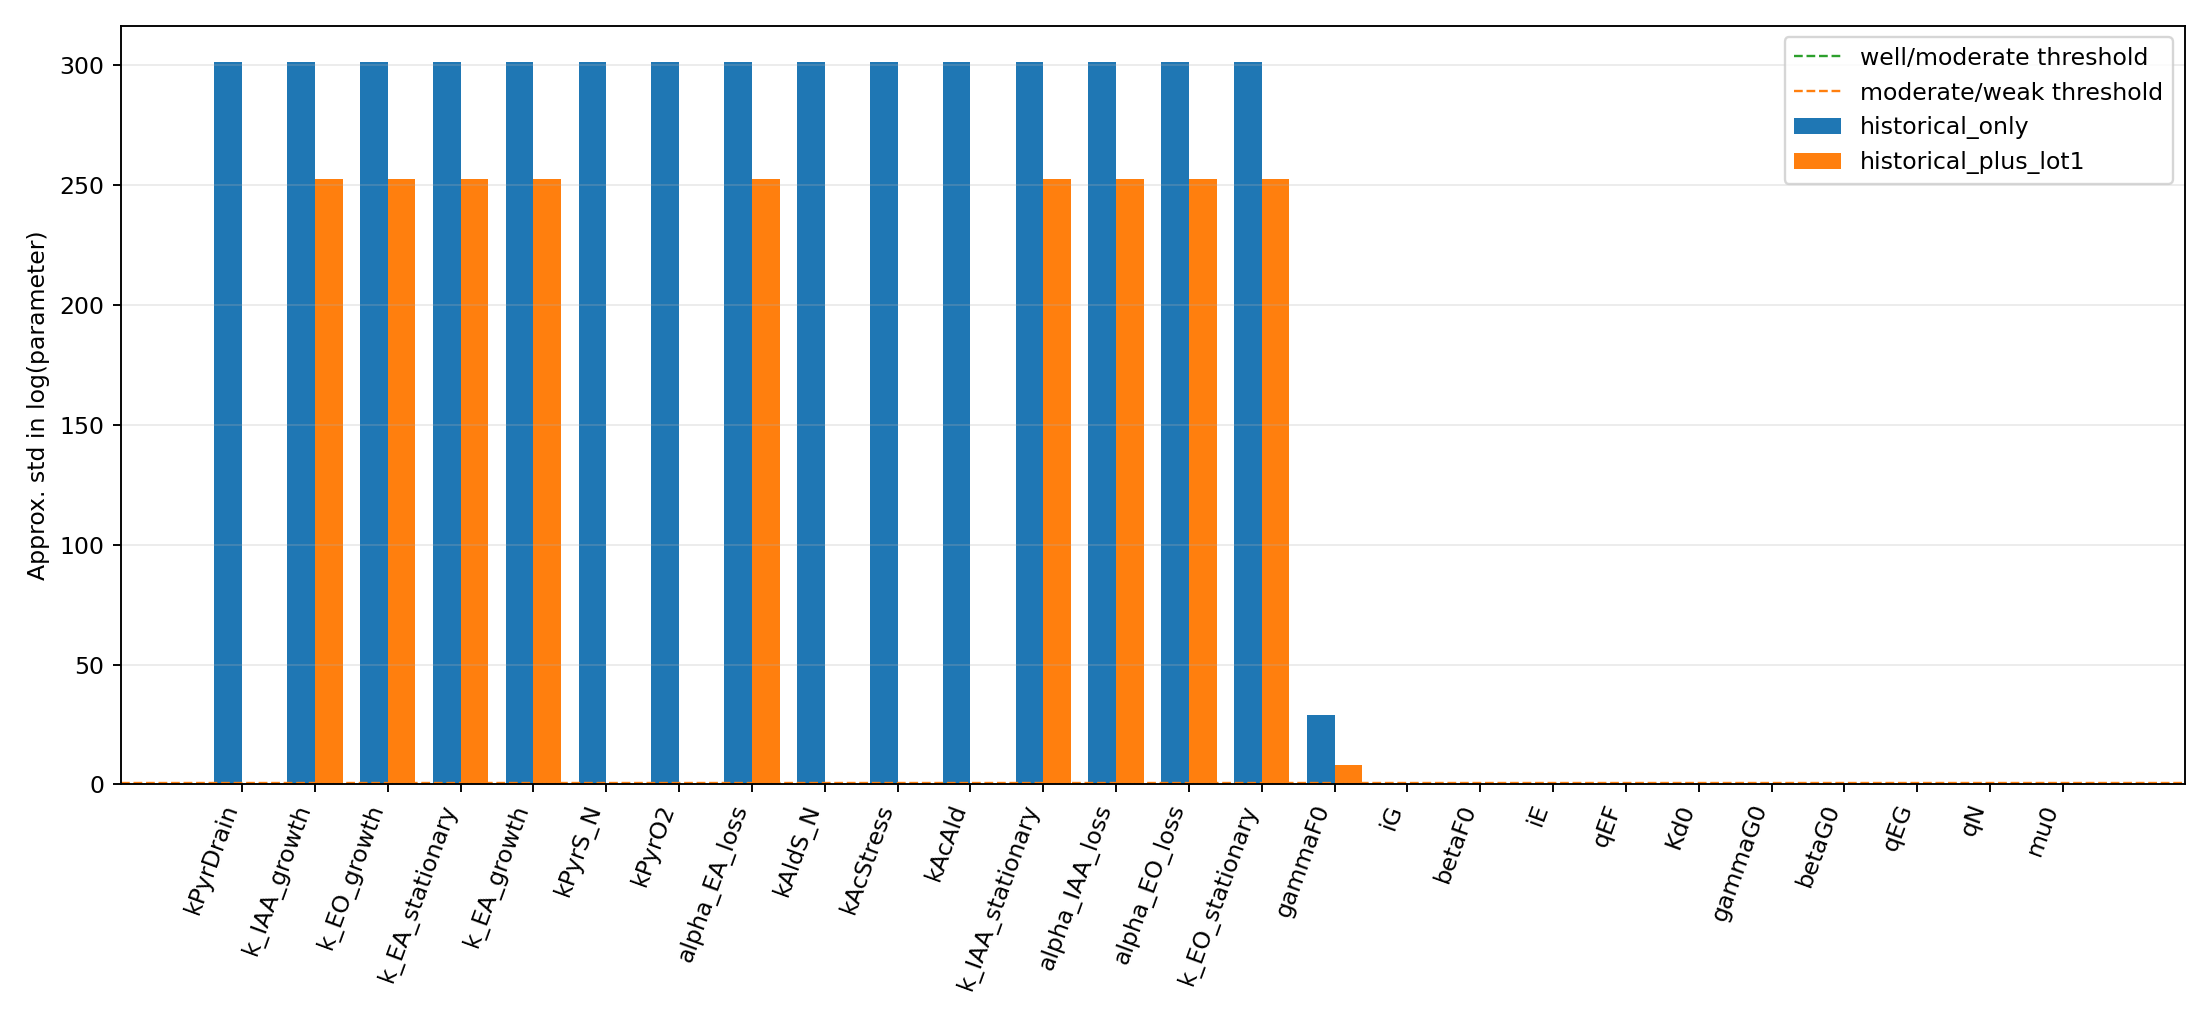

In [6]:
display(Image(filename=str(RESULTS / "figures" / "estimability_std_log_comparison.png")))

## Weak Eigen Directions

In [7]:
weak = pd.read_csv(RESULTS / "weak_directions_extended_by_case.csv")
display(weak)

,case,weak_direction,eigenvalue,dominant_parameters,dominant_abs_loadings
0,historical_only,1,0.0,"kPyrS_N, alpha_EO_loss, alpha_IAA_loss, qN, be...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
1,historical_only,2,0.0,"alpha_EO_loss, alpha_IAA_loss, qN, betaG0, bet...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
2,historical_only,3,0.0,"alpha_IAA_loss, alpha_EO_loss, qN, betaG0, bet...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
3,historical_only,4,0.0,"k_EO_stationary, alpha_EO_loss, kPyrS_N, qN, b...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
4,historical_only,5,0.0,"k_EO_growth, alpha_EO_loss, kPyrS_N, qN, betaG...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
5,historical_only,6,0.0,"k_IAA_stationary, alpha_EO_loss, kPyrS_N, qN, ...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
6,historical_only,7,0.0,"k_IAA_growth, alpha_EO_loss, kPyrS_N, qN, beta...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
7,historical_only,8,0.0,"alpha_EA_loss, alpha_EO_loss, kPyrS_N, qN, bet...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
8,historical_plus_lot1,1,0.0,"k_EA_growth, alpha_EO_loss, kPyrS_N, qN, betaG...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"
9,historical_plus_lot1,2,0.0,"k_EA_stationary, alpha_EO_loss, kPyrS_N, qN, b...","1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000"


## Profile Likelihood

In [8]:
profile_summary = pd.read_csv(RESULTS / "profile_likelihood_summary_core_by_case.csv")
profile = pd.read_csv(RESULTS / "profile_likelihood_core_by_case.csv")
display(profile_summary)
display(profile.head(30))

,case,parameter,n_success,max_lr_stat,crosses_left_95,crosses_right_95,profile_identifiable_95,chi2_95_threshold
0,historical_only,Kd0,4,462.483153,True,True,True,3.841459
1,historical_only,qN,4,5131.629030,True,True,True,3.841459
2,historical_plus_lot1,Kd0,4,418.091751,True,True,True,3.841459
3,historical_plus_lot1,qN,4,13367.257481,True,True,True,3.841459


,case,profiled_parameter,theta_hat,theta_value,success,objective,lr_stat,chi2_95_threshold,error
0,historical_only,Kd0,0.000754,0.000377,True,24023.824890,164.216466,3.841459,NaN
1,historical_only,Kd0,0.000754,0.000754,True,23859.608424,0.000000,3.841459,NaN
2,historical_only,Kd0,0.000754,0.000942,True,23917.762015,58.153591,3.841459,NaN
3,historical_only,Kd0,0.000754,0.001508,True,24322.091578,462.483153,3.841459,NaN
4,historical_only,qN,0.014940,0.007470,True,28991.237455,5131.629030,3.841459,NaN
5,historical_only,qN,0.014940,0.014940,True,23859.608424,0.000000,3.841459,NaN
6,historical_only,qN,0.014940,0.018675,True,24294.001926,434.393501,3.841459,NaN
7,historical_only,qN,0.014940,0.029880,True,26152.825163,2293.216738,3.841459,NaN
8,historical_plus_lot1,Kd0,0.000907,0.000453,True,36474.373211,217.839976,3.841459,NaN
9,historical_plus_lot1,Kd0,0.000907,0.000907,True,36256.533236,0.000000,3.841459,NaN


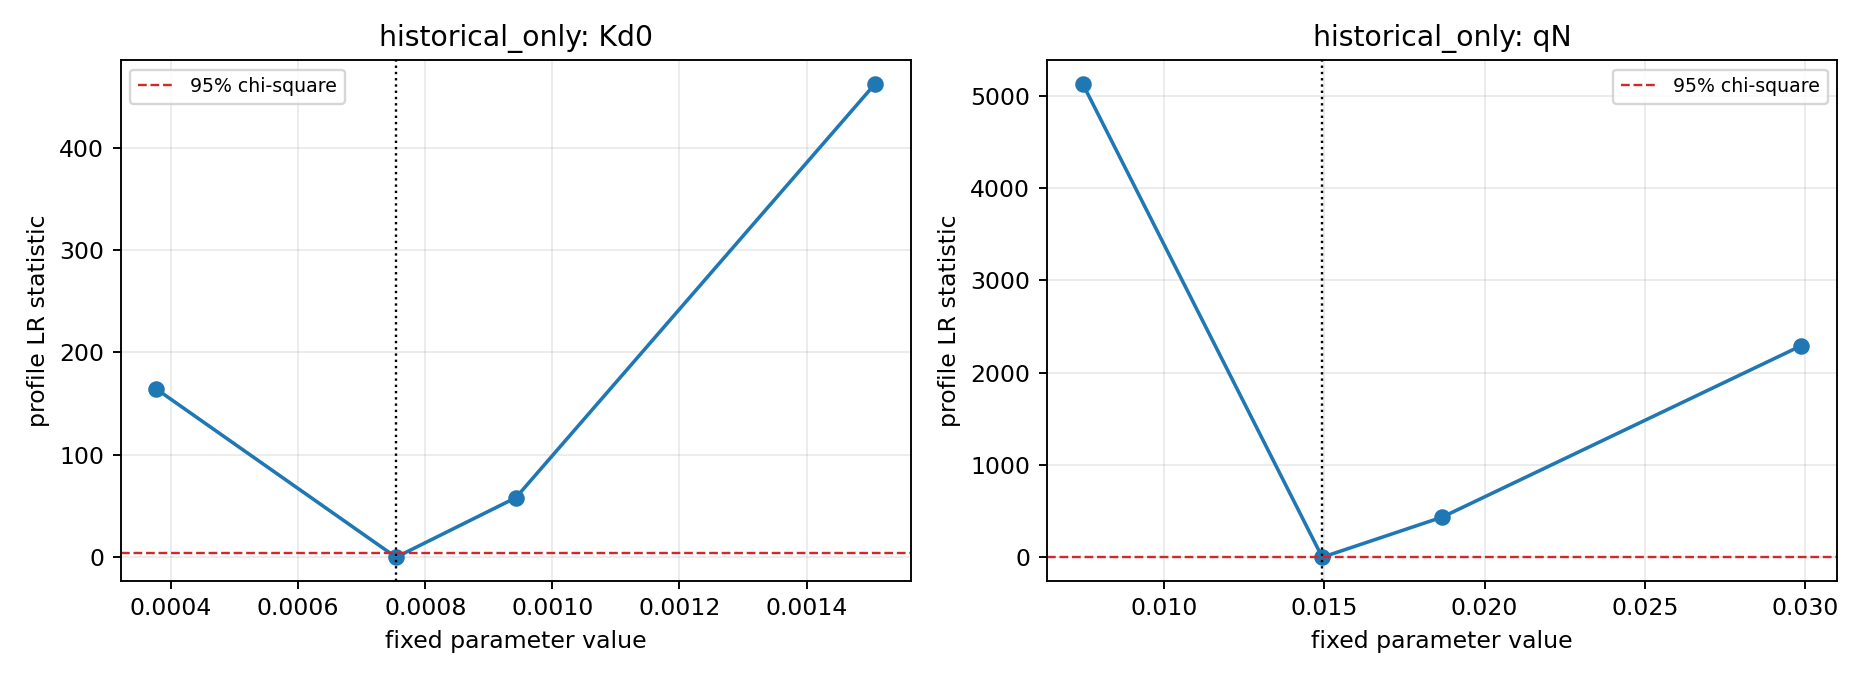

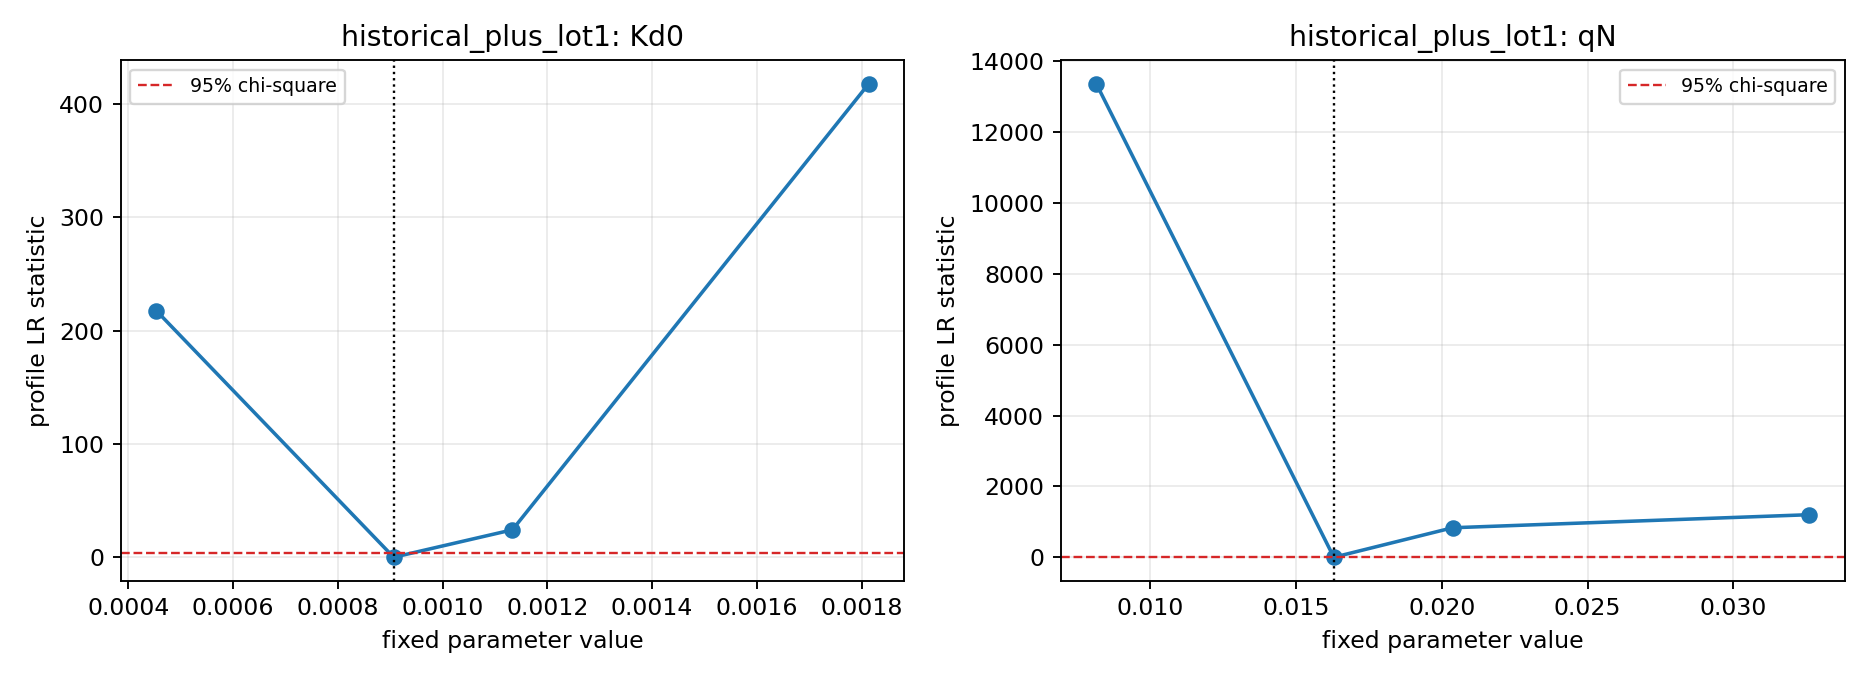

In [9]:
display(Image(filename=str(RESULTS / "figures" / "profile_likelihood_historical_only.png")))
display(Image(filename=str(RESULTS / "figures" / "profile_likelihood_historical_plus_lot1.png")))

## Report

In [10]:
report = (RESULTS / "estimability_old_vs_lot1_report.md").read_text(encoding="utf-8")
print(report)

# Estimability: historical data vs historical + Lot 1

## What was compared

Two information sets were evaluated with the same model and parameter set:

1. `historical_only`: the normalized historical natural/synthetic must database.
2. `historical_plus_lot1`: historical data plus the executed Lot 1 batches reconstructed from `fermentation_lot1_data_preview.executed.ipynb`.

The extended FIM uses observed core states and secondary states where available. Lot 1 online CO2 is included as an information-time block because the current model state is cumulative CO2, whereas the sensor reports gas flow; this should be interpreted as information availability, not as a final calibrated CO2 likelihood.

## FIM Metrics

|    logdet |   min_eigenvalue |   max_eigenvalue |   min_relative_eigenvalue |   condition_number |        trace_inv |   rank_1e-8 | case                 | block                                  |   n_parameters |
|----------:|-----------------:|-----------------:|--------------